In [1]:
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
import pandas as pd
from datetime import datetime

# 1. Define Parameters
ticker = "FUND"
start_date = "2019-01-01"
end_date = datetime.now().strftime('%Y-%m-%d')

# 2. Fetch Developed ex-US 3-Factors (Mkt, SMB, HML)
ds_3_factors = web.DataReader('Developed_ex_US_3_Factors', 'famafrench', start_date, end_date)
df_3_factors = ds_3_factors[0] / 100

# 3. Fetch Developed ex-US Momentum Factor (WML)
ds_mom = web.DataReader('Developed_ex_US_Mom_Factor', 'famafrench', start_date, end_date)
df_mom = ds_mom[0] / 100
df_mom.columns = ['WML'] # Rename 'Mom' to 'WML' (Winners Minus Losers)

# 4. Download FUND Returns
fund_data = yf.download(ticker, start=start_date, end=end_date, interval='1mo', auto_adjust=False)['Adj Close']
fund_returns = fund_data.pct_change().dropna()
fund_returns.index = fund_returns.index.to_period('M')

# 5. Merge and Calculate Excess Returns
data = pd.concat([fund_returns, df_3_factors, df_mom], axis=1).dropna()
data['Excess_Return'] = data[ticker] - data['RF']

# 6. Run 4-Factor Regression
# Formula: Excess_Return ~ Alpha + Mkt-RF + SMB + HML + WML
X = data[['Mkt-RF', 'SMB', 'HML', 'WML']]
X = sm.add_constant(X)
y = data['Excess_Return']

model = sm.OLS(y, X).fit()

# 7. Final Attribution Output
print(f"--- 4-Factor Attribution (International): {ticker} ---")
print(model.summary())

# Extractized Annualized Alpha
monthly_alpha = model.params['const']
annualized_alpha = (1 + monthly_alpha)**12 - 1
print(f"\n4-Factor Annualized Alpha: {annualized_alpha:.2%}")

/tmp/ipykernel_14272/2209081810.py:13: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds_3_factors = web.DataReader('Developed_ex_US_3_Factors', 'famafrench', start_date, end_date)
/tmp/ipykernel_14272/2209081810.py:13: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds_3_factors = web.DataReader('Developed_ex_US_3_Factors', 'famafrench', start_date, end_date)
/tmp/ipykernel_14272/2209081810.py:17: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds_mom = web.DataReader('Developed_ex_US_Mom_Factor', 'famafrench', start_date, end_date)


--- 4-Factor Attribution (International): FUND ---
                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     55.68
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           6.84e-21
Time:                        12:43:07   Log-Likelihood:                 142.58
No. Observations:                  74   AIC:                            -275.2
Df Residuals:                      69   BIC:                            -263.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c

In [6]:
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
import pandas as pd
from datetime import datetime

# 1. Define Parameters
ticker = "FUND"
start_date = "2019-01-01"
end_date = datetime.now().strftime('%Y-%m-%d')

# 2. Fetch International (Ex-US) 3-Factor Data
# 'Developed_ex_US_3_Factors' contains Mkt-RF, SMB, and HML for non-US markets
ds_factors = web.DataReader('Developed_ex_US_3_Factors', 'famafrench', start_date, end_date)
ff_intl = ds_factors[0] / 100  # Monthly factors are in index 0

# 3. Download Fund Data (FUND)
fund = yf.download(ticker, start='2019-01-01', interval='1mo', auto_adjust=False)['Adj Close'].pct_change().dropna()
fund_returns = fund

# 4. Align Data
fund_returns.index = fund_returns.index.to_period('M')
data = pd.concat([fund_returns, ff_intl], axis=1).dropna()

# 5. Calculate Excess Returns
# Note: Use the 'RF' (Risk-Free Rate) provided in the International dataset
data['Excess_Return'] = data[ticker] - data['RF']

# 6. Regression: Excess_Return ~ Alpha + Beta1*Mkt-RF + Beta2*SMB + Beta3*HML
X = data[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X)
y = data['Excess_Return']

model = sm.OLS(y, X).fit()

# 7. Results
print(f"--- International Factor Attribution: {ticker} ---")
print(model.summary())

# Annualized Alpha calculation
monthly_alpha = model.params['const']
annualized_alpha = (1 + monthly_alpha)**12 - 1

print(f"\nMonthly Alpha: {monthly_alpha:.4%}")
print(f"Annualized Alpha (Risk-Adjusted): {annualized_alpha:.2%}")

/tmp/ipykernel_14272/3036701158.py:14: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds_factors = web.DataReader('Developed_ex_US_3_Factors', 'famafrench', start_date, end_date)
/tmp/ipykernel_14272/3036701158.py:14: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds_factors = web.DataReader('Developed_ex_US_3_Factors', 'famafrench', start_date, end_date)
[*********************100%***********************]  1 of 1 completed

--- International Factor Attribution: FUND ---
                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     73.89
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.20e-21
Time:                        14:32:46   Log-Likelihood:                 142.04
No. Observations:                  74   AIC:                            -276.1
Df Residuals:                      70   BIC:                            -266.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

/tmp/ipykernel_14272/859504587.py:10: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds_3 = web.DataReader('Developed_ex_US_3_Factors', 'famafrench', '2019-01-01')[0] / 100
/tmp/ipykernel_14272/859504587.py:10: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds_3 = web.DataReader('Developed_ex_US_3_Factors', 'famafrench', '2019-01-01')[0] / 100
/tmp/ipykernel_14272/859504587.py:11: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ds_mom = web.DataReader('Developed_ex_US_Mom_Factor', 'famafrench', '2019-01-01')[0] / 100
[***************

<Axes: title={'center': 'Dataset Rolling 12M Annualized Alpha'}, xlabel='Date'>

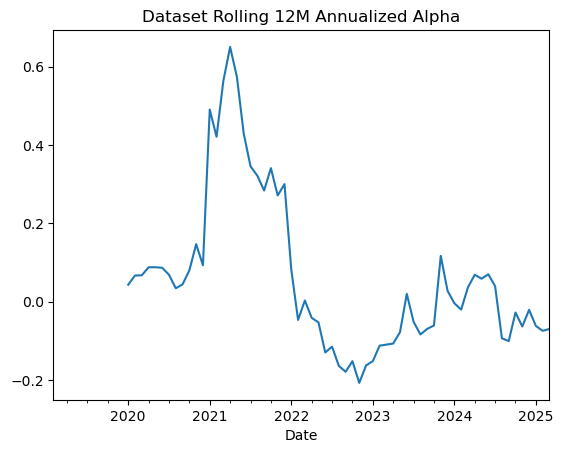

In [5]:
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import pandas as pd

# 1. Setup
ticker = "FUND"
# Fetch Developed Ex-US 3-Factors + Momentum
ds_3 = web.DataReader('Developed_ex_US_3_Factors', 'famafrench', '2019-01-01')[0] / 100
ds_mom = web.DataReader('Developed_ex_US_Mom_Factor', 'famafrench', '2019-01-01')[0] / 100
ds_mom.columns = ['WML']

# 2. Get Fund Returns
fund = yf.download(ticker, start='2019-01-01', interval='1mo', auto_adjust=False)['Adj Close'].pct_change().dropna()
fund.index = fund.index.to_period('M')
fund_returns = fund

# 3. Combine and Regress
data = pd.concat([fund, ds_3, ds_mom], axis=1).dropna()
data['Excess_Return'] = data[ticker] - data['RF']

X = sm.add_constant(data[['Mkt-RF', 'SMB', 'HML', 'WML']])
rols = RollingOLS(data['Excess_Return'], X, window=12).fit()

# 4. Annualize Rolling Alpha
rolling_alpha_ann = (1 + rols.params['const'])**12 - 1
rolling_alpha_ann.plot(title=f"Dataset Rolling 12M Annualized Alpha")